# Final
# ROC Curve and Venn Diagram: GOEnrich vs. g:Profiler Comparison

In this analysis, we compare two sets of enrichment results:
- **GOEnrich’s Results:** Loaded from a TSV file (which reports GO terms along with FDR values).
- **g:Profiler Results:** Loaded from a CSV file (which reports GO terms along with adjusted p‑values).

For each method, we:
- Compute a continuous score defined as –log₁₀(FDR) (or –log₁₀(adjusted p‑value)) so that higher scores indicate stronger enrichment.
- Mark a term as "true" if it is in the ground‐truth (SOT) set extracted from the diffexp file.
- Exclude any SOT term that is not reported by the method.

We then compute ROC curves for each method and annotate:
- The fixed significance threshold (p < 0.05, corresponding to a score of ~1.30).
- The “SOT threshold” (the minimum score among the SOT terms within that output).

Finally, a Venn diagram shows the overlap of:
- The SOT set (as reported by each method),
- GOEnrich’s significant terms (FDR < 0.05), and
- g:Profiler’s significant terms (adjusted p‑value < 0.05).

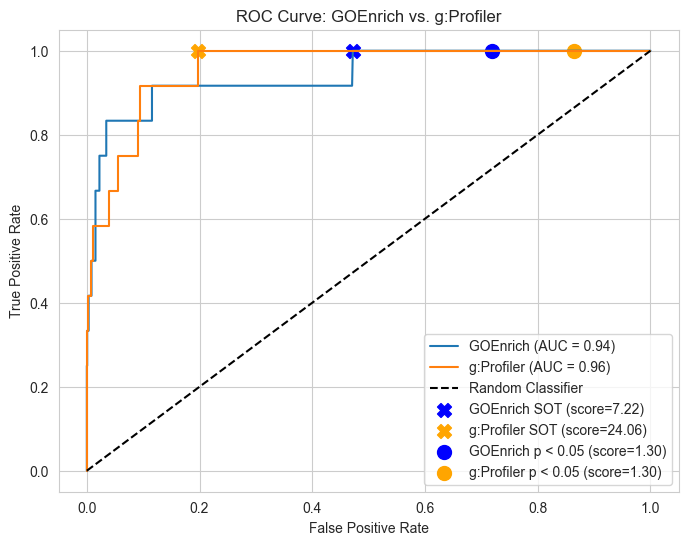

GOEnrich:
  SOT threshold (score = 7.22): TPR = 1.00, FPR = 0.47
  Fixed threshold (score = 1.30): TPR = 1.00, FPR = 0.72

g:Profiler:
  SOT threshold (score = 24.06): TPR = 1.00, FPR = 0.20
  Fixed threshold (score = 1.30): TPR = 1.00, FPR = 0.86


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc

# -----------------------------
# Part A: Extract Ground-Truth (SOT) Terms
# -----------------------------
diffexp_file = "../../../../data/GOEnrichment/simul_exp_go_bp_ensembl.tsv"
ground_truth_terms = set()
with open(diffexp_file, "r") as f:
    for line in f:
        if line.startswith('#'):
            term = line.lstrip('#').strip()
            if term:
                ground_truth_terms.add(term)

# -----------------------------
# Part B: Load GOEnrich's TSV Results (Only Reported Terms)
# -----------------------------
my_tool_file = "../../../../data/GOEnrichment/Runs/out_ensembl_bp.tsv"
df_my_tool = pd.read_csv(my_tool_file, sep='\t')
# Assume df_my_tool has at least the columns: "term" and "fej_fdr"
# Mark a term as true only if it is reported AND it is in the SOT set.
df_my_tool["is_true"] = df_my_tool["term"].apply(lambda x: x in ground_truth_terms)
epsilon = 1e-300  # to avoid log(0)
df_my_tool["score"] = -np.log10(df_my_tool["fej_fdr"] + epsilon)

# -----------------------------
# Part C: Load g:Profiler Results (Only Reported Terms)
# -----------------------------
gprofiler_file = "gProfiler_hsapiens_2-8-2025_2-14-32 PM__intersections.csv"
df_gprofiler = pd.read_csv(gprofiler_file)
# Assume df_gprofiler has columns: "term_id" and "adjusted_p_value"
df_gprofiler["is_true"] = df_gprofiler["term_id"].apply(lambda x: x in ground_truth_terms)
df_gprofiler["score"] = -np.log10(df_gprofiler["adjusted_p_value"] + epsilon)

# -----------------------------
# Part D: Compute ROC Curves for Each Method
# -----------------------------
# For GOEnrich:
y_true_my = df_my_tool["is_true"]
scores_my = df_my_tool["score"]
fpr_my, tpr_my, _ = roc_curve(y_true_my, scores_my)
auc_my = auc(fpr_my, tpr_my)

# For g:Profiler:
y_true_gp = df_gprofiler["is_true"]
scores_gp = df_gprofiler["score"]
fpr_gp, tpr_gp, _ = roc_curve(y_true_gp, scores_gp)
auc_gp = auc(fpr_gp, tpr_gp)

# -----------------------------
# Part E: Determine Thresholds and Annotate
# -----------------------------
# For each method, the "SOT threshold" is the minimum score among terms that are SOT (reported by that method).
if any(y_true_my):
    sot_thresh_my = df_my_tool.loc[df_my_tool["is_true"], "score"].min()
else:
    sot_thresh_my = np.nan

if any(y_true_gp):
    sot_thresh_gp = df_gprofiler.loc[df_gprofiler["is_true"], "score"].min()
else:
    sot_thresh_gp = np.nan

# Fixed significance threshold corresponding to p < 0.05.
signif_thresh = -np.log10(0.05 + epsilon)  # ~1.30

# Compute performance at these thresholds.
# GOEnrich:
df_my_tool["pred_sot"] = df_my_tool["score"] >= sot_thresh_my
df_my_tool["pred_signif"] = df_my_tool["score"] >= signif_thresh

TP_my_sot = np.sum(y_true_my & df_my_tool["pred_sot"])
FN_my_sot = np.sum(y_true_my & ~df_my_tool["pred_sot"])
FP_my_sot = np.sum(~y_true_my & df_my_tool["pred_sot"])
TN_my_sot = np.sum(~y_true_my & ~df_my_tool["pred_sot"])
tpr_my_sot = TP_my_sot / (TP_my_sot + FN_my_sot) if (TP_my_sot + FN_my_sot) > 0 else 0
fpr_my_sot = FP_my_sot / (FP_my_sot + TN_my_sot) if (FP_my_sot + TN_my_sot) > 0 else 0

df_my_tool["pred_signif"] = df_my_tool["score"] >= signif_thresh
TP_my_signif = np.sum(y_true_my & df_my_tool["pred_signif"])
FN_my_signif = np.sum(y_true_my & ~df_my_tool["pred_signif"])
FP_my_signif = np.sum(~y_true_my & df_my_tool["pred_signif"])
TN_my_signif = np.sum(~y_true_my & ~df_my_tool["pred_signif"])
tpr_my_signif = TP_my_signif / (TP_my_signif + FN_my_signif) if (TP_my_signif + FN_my_signif) > 0 else 0
fpr_my_signif = FP_my_signif / (FP_my_signif + TN_my_signif) if (FP_my_signif + TN_my_signif) > 0 else 0

# g:Profiler:
df_gprofiler["pred_sot"] = df_gprofiler["score"] >= sot_thresh_gp
df_gprofiler["pred_signif"] = df_gprofiler["score"] >= signif_thresh

TP_gp_sot = np.sum(y_true_gp & df_gprofiler["pred_sot"])
FN_gp_sot = np.sum(y_true_gp & ~df_gprofiler["pred_sot"])
FP_gp_sot = np.sum(~y_true_gp & df_gprofiler["pred_sot"])
TN_gp_sot = np.sum(~y_true_gp & ~df_gprofiler["pred_sot"])
tpr_gp_sot = TP_gp_sot / (TP_gp_sot + FN_gp_sot) if (TP_gp_sot + FN_gp_sot) > 0 else 0
fpr_gp_sot = FP_gp_sot / (FP_gp_sot + TN_gp_sot) if (FP_gp_sot + TN_gp_sot) > 0 else 0

TP_gp_signif = np.sum(y_true_gp & df_gprofiler["pred_signif"])
FN_gp_signif = np.sum(y_true_gp & ~df_gprofiler["pred_signif"])
FP_gp_signif = np.sum(~y_true_gp & df_gprofiler["pred_signif"])
TN_gp_signif = np.sum(~y_true_gp & ~df_gprofiler["pred_signif"])
tpr_gp_signif = TP_gp_signif / (TP_gp_signif + FN_gp_signif) if (TP_gp_signif + FN_gp_signif) > 0 else 0
fpr_gp_signif = FP_gp_signif / (FP_gp_signif + TN_gp_signif) if (FP_gp_signif + TN_gp_signif) > 0 else 0

# -----------------------------
# Part F: Plot ROC Curves with Annotations
# -----------------------------
plt.figure(figsize=(8, 6))
plt.plot(fpr_my, tpr_my, label=f'GOEnrich (AUC = {auc_my:.2f})')
plt.plot(fpr_gp, tpr_gp, label=f'g:Profiler (AUC = {auc_gp:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.scatter(fpr_my_sot, tpr_my_sot, color='blue', marker='X', s=100,
            label=f'GOEnrich SOT (score={sot_thresh_my:.2f})')
plt.scatter(fpr_gp_sot, tpr_gp_sot, color='orange', marker='X', s=100,
            label=f'g:Profiler SOT (score={sot_thresh_gp:.2f})')

plt.scatter(fpr_my_signif, tpr_my_signif, color='blue', marker='o', s=100,
            label=f'GOEnrich p < 0.05 (score={signif_thresh:.2f})')
plt.scatter(fpr_gp_signif, tpr_gp_signif, color='orange', marker='o', s=100,
            label=f'g:Profiler p < 0.05 (score={signif_thresh:.2f})')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: GOEnrich vs. g:Profiler")
plt.legend(loc="lower right")
plt.savefig("plots/GProfiler_Comparison_ROC.pdf")
plt.show()

# Print performance metrics.
print("GOEnrich:")
print("  SOT threshold (score = {:.2f}): TPR = {:.2f}, FPR = {:.2f}".format(sot_thresh_my, tpr_my_sot, fpr_my_sot))
print("  Fixed threshold (score = {:.2f}): TPR = {:.2f}, FPR = {:.2f}".format(signif_thresh, tpr_my_signif,
                                                                              fpr_my_signif))
print("\ng:Profiler:")
print("  SOT threshold (score = {:.2f}): TPR = {:.2f}, FPR = {:.2f}".format(sot_thresh_gp, tpr_gp_sot, fpr_gp_sot))
print("  Fixed threshold (score = {:.2f}): TPR = {:.2f}, FPR = {:.2f}".format(signif_thresh, tpr_gp_signif,
                                                                              fpr_gp_signif))



# Venn Diagram: SOT Terms vs. Significant GO Terms

Below we compare:
- **SOT Terms:** The ground-truth set extracted from the diffexp file.
- **GOEnrich Significant Terms:** GO terms from your TSV results with FDR < 0.05.
- **g:Profiler Significant Terms:** GO terms from the g:Profiler output with adjusted p‑value < 0.05.

In each case, only the reported terms are used.

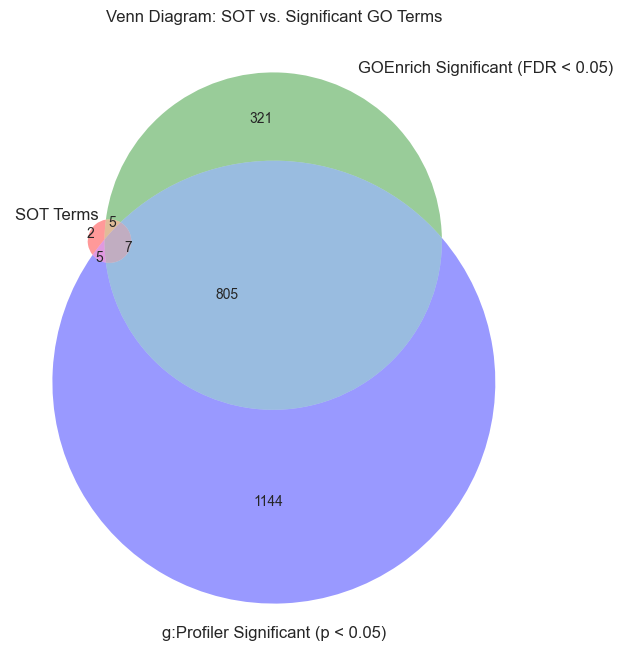

In [9]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# For GOEnrich, use only its reported significant terms.
set_my_tool_signif = set(df_my_tool[df_my_tool["fej_fdr"] < 0.05]["term"])
# For g:Profiler, use its reported significant terms.
set_gprofiler_signif = set(df_gprofiler[df_gprofiler["adjusted_p_value"] < 0.05]["term_id"])
# Ground-truth SOT terms (as provided in the diffexp file).
set_sot = ground_truth_terms

plt.figure(figsize=(8, 8))
venn3([set_sot, set_my_tool_signif, set_gprofiler_signif],
      set_labels=("SOT Terms", "GOEnrich Significant (FDR < 0.05)", "g:Profiler Significant (p < 0.05)"))
plt.title("Venn Diagram: SOT vs. Significant GO Terms")
plt.savefig("plots/GProfiler_Comparison_Venn.pdf")
plt.show()


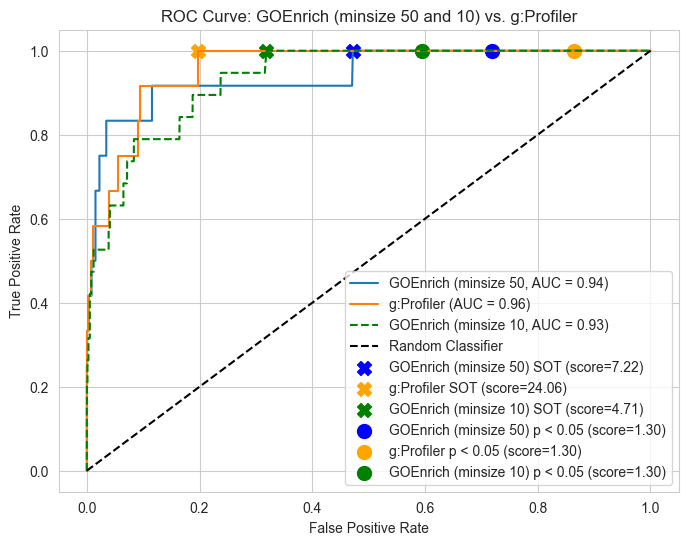

GOEnrich (minsize 50):
  SOT threshold (score = 7.22): TPR = 1.00, FPR = 0.47
  Fixed threshold (score = 1.30): TPR = 1.00, FPR = 0.72

GOEnrich (minsize 10):
  SOT threshold (score = 4.71): TPR = 1.00, FPR = 0.32
  Fixed threshold (score = 1.30): TPR = 1.00, FPR = 0.59

g:Profiler:
  SOT threshold (score = 24.06): TPR = 1.00, FPR = 0.20
  Fixed threshold (score = 1.30): TPR = 1.00, FPR = 0.86


<Figure size 1000x1000 with 0 Axes>

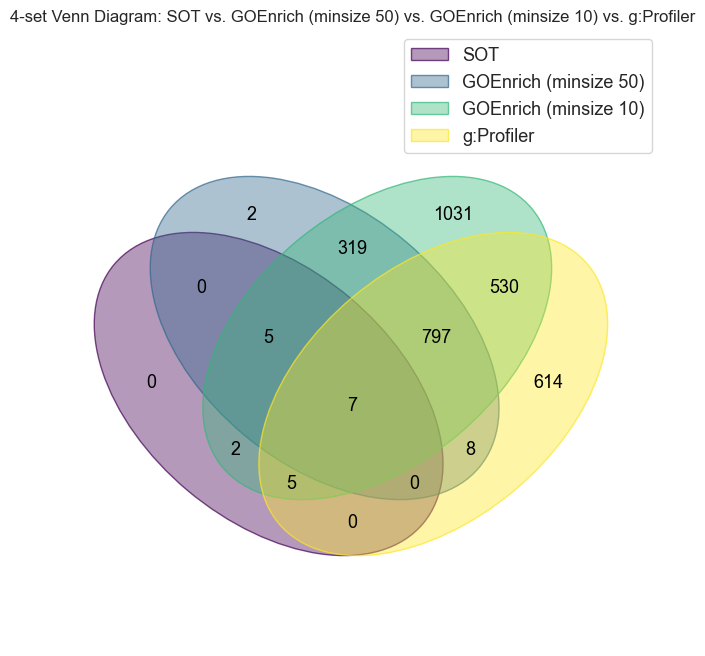

In [12]:
# -----------------------------
# Part G: Process Additional Output (minsize 10) from out-all.tsv
# -----------------------------
# Load the new output file.
new_output_file = "../../../../data/GOEnrichment/Runs/out-all.tsv"
df_new = pd.read_csv(new_output_file, sep='\t')
# Assume df_new has columns: "term" and "fej_fdr"
df_new["is_true"] = df_new["term"].apply(lambda x: x in ground_truth_terms)
df_new["score"] = -np.log10(df_new["fej_fdr"] + epsilon)

# Compute ROC curve for new output.
y_true_new = df_new["is_true"]
scores_new = df_new["score"]
fpr_new, tpr_new, _ = roc_curve(y_true_new, scores_new)
auc_new = auc(fpr_new, tpr_new)

# Determine thresholds for new output.
if any(y_true_new):
    sot_thresh_new = df_new.loc[df_new["is_true"], "score"].min()
else:
    sot_thresh_new = np.nan
# Fixed threshold remains the same.
signif_thresh = -np.log10(0.05 + epsilon)  # ~1.30

# Compute predictions at these thresholds.
df_new["pred_sot"] = df_new["score"] >= sot_thresh_new
df_new["pred_signif"] = df_new["score"] >= signif_thresh

TP_new_sot = np.sum(y_true_new & df_new["pred_sot"])
FN_new_sot = np.sum(y_true_new & ~df_new["pred_sot"])
FP_new_sot = np.sum(~y_true_new & df_new["pred_sot"])
TN_new_sot = np.sum(~y_true_new & ~df_new["pred_sot"])
tpr_new_sot = TP_new_sot / (TP_new_sot + FN_new_sot) if (TP_new_sot + FN_new_sot) > 0 else 0
fpr_new_sot = FP_new_sot / (FP_new_sot + TN_new_sot) if (FP_new_sot + TN_new_sot) > 0 else 0

df_new["pred_signif"] = df_new["score"] >= signif_thresh
TP_new_signif = np.sum(y_true_new & df_new["pred_signif"])
FN_new_signif = np.sum(y_true_new & ~df_new["pred_signif"])
FP_new_signif = np.sum(~y_true_new & df_new["pred_signif"])
TN_new_signif = np.sum(~y_true_new & ~df_new["pred_signif"])
tpr_new_signif = TP_new_signif / (TP_new_signif + FN_new_signif) if (TP_new_signif + FN_new_signif) > 0 else 0
fpr_new_signif = FP_new_signif / (FP_new_signif + TN_new_signif) if (FP_new_signif + TN_new_signif) > 0 else 0

# -----------------------------
# Part H: Add New Output to ROC Plot
# -----------------------------
plt.figure(figsize=(8, 6))
# Original ROC curves.
plt.plot(fpr_my, tpr_my, label=f'GOEnrich (minsize 50, AUC = {auc_my:.2f})')
plt.plot(fpr_gp, tpr_gp, label=f'g:Profiler (AUC = {auc_gp:.2f})')
# New output ROC curve.
plt.plot(fpr_new, tpr_new, label=f'GOEnrich (minsize 10, AUC = {auc_new:.2f})', linestyle='--', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Annotate thresholds for original and new outputs.
plt.scatter(fpr_my_sot, tpr_my_sot, color='blue', marker='X', s=100,
            label=f'GOEnrich (minsize 50) SOT (score={sot_thresh_my:.2f})')
plt.scatter(fpr_gp_sot, tpr_gp_sot, color='orange', marker='X', s=100,
            label=f'g:Profiler SOT (score={sot_thresh_gp:.2f})')
plt.scatter(fpr_new_sot, tpr_new_sot, color='green', marker='X', s=100,
            label=f'GOEnrich (minsize 10) SOT (score={sot_thresh_new:.2f})')

plt.scatter(fpr_my_signif, tpr_my_signif, color='blue', marker='o', s=100,
            label=f'GOEnrich (minsize 50) p < 0.05 (score={signif_thresh:.2f})')
plt.scatter(fpr_gp_signif, tpr_gp_signif, color='orange', marker='o', s=100,
            label=f'g:Profiler p < 0.05 (score={signif_thresh:.2f})')
plt.scatter(fpr_new_signif, tpr_new_signif, color='green', marker='o', s=100,
            label=f'GOEnrich (minsize 10) p < 0.05 (score={signif_thresh:.2f})')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: GOEnrich (minsize 50 and 10) vs. g:Profiler")
plt.legend(loc="lower right")
plt.savefig("plots/GProfiler_Comparison_ROC_ALL.pdf")
plt.show()
# Print performance metrics for each method.

print("GOEnrich (minsize 50):")
print("  SOT threshold (score = {:.2f}): TPR = {:.2f}, FPR = {:.2f}".format(sot_thresh_my, tpr_my_sot, fpr_my_sot))
print("  Fixed threshold (score = {:.2f}): TPR = {:.2f}, FPR = {:.2f}".format(signif_thresh, tpr_my_signif,
                                                                              fpr_my_signif))
print("\nGOEnrich (minsize 10):")
print("  SOT threshold (score = {:.2f}): TPR = {:.2f}, FPR = {:.2f}".format(sot_thresh_new, tpr_new_sot, fpr_new_sot))
print("  Fixed threshold (score = {:.2f}): TPR = {:.2f}, FPR = {:.2f}".format(signif_thresh, tpr_new_signif,
                                                                              fpr_new_signif))
print("\ng:Profiler:")
print("  SOT threshold (score = {:.2f}): TPR = {:.2f}, FPR = {:.2f}".format(sot_thresh_gp, tpr_gp_sot, fpr_gp_sot))
print("  Fixed threshold (score = {:.2f}): TPR = {:.2f}, FPR = {:.2f}".format(signif_thresh, tpr_gp_signif,
                                                                              fpr_gp_signif))
# -----------------------------
# Part I: Create Venn Diagram for New Output
# -----------------------------
# For the original venn diagram, we used the significant terms (FDR < 0.05) from the original output.
# Here, we create an additional venn diagram comparing SOT, GOEnrich (minsize 10), and g:Profiler.
set_new_signif = set(
    df_new[df_new["fej_fdr"] < 0.05]["term"])  # if 'fej_fdr' exists in out-all.tsv; otherwise use appropriate column
# If the new file uses the same column names as the original TSV, then:
set_new_signif = set(df_new[df_new["fej_fdr"] < 0.05]["term"])
set_gp_signif = set(df_gprofiler[df_gprofiler["adjusted_p_value"] < 0.05]["term_id"])
set_sot = ground_truth_terms

venn_data = {
    "SOT": ground_truth_terms,
    "GOEnrich (minsize 50)": set_my_tool_signif,
    "GOEnrich (minsize 10)": set_new_signif,
    "g:Profiler": set_gprofiler_signif
}
from venn import venn

plt.figure(figsize=(10, 10))
venn(venn_data)
plt.title("4-set Venn Diagram: SOT vs. GOEnrich (minsize 50) vs. GOEnrich (minsize 10) vs. g:Profiler")
plt.savefig("plots/GProfiler_Comparison_Venn_4set.pdf")
plt.show()

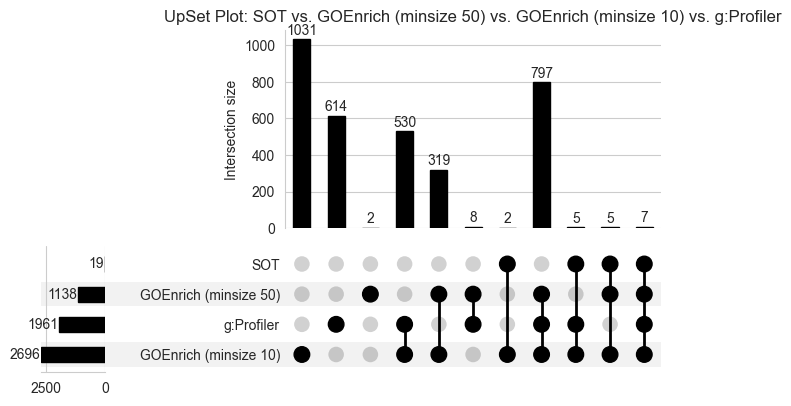

In [11]:
from upsetplot import UpSet, from_memberships

all_terms = ground_truth_terms.union(set_my_tool_signif).union(set_new_signif).union(set_gprofiler_signif)
memberships = []
for term in all_terms:
    membership = []
    if term in ground_truth_terms:
        membership.append("SOT")
    if term in set_my_tool_signif:
        membership.append("GOEnrich (minsize 50)")
    if term in set_new_signif:
        membership.append("GOEnrich (minsize 10)")
    if term in set_gprofiler_signif:
        membership.append("g:Profiler")
    memberships.append(membership)

# Convert memberships into a format suitable for an UpSet plot.
data = from_memberships(memberships)

# Generate the UpSet plot.
up = UpSet(data, subset_size='count', show_counts=True)
up.plot()
plt.title("UpSet Plot: SOT vs. GOEnrich (minsize 50) vs. GOEnrich (minsize 10) vs. g:Profiler")
plt.savefig("plots/GProfiler_Comparison_UpSet.pdf")
plt.show()